# Module 1 Mini Project: Complete Iris Classification Pipeline

## This script demonstrates the full Scikit-learn workflow:
### Data loading and exploration
### Preprocessing (feature selection, scaling)
### Model training (multiple classifiers)
### Evaluation and comparison
### Prediction on new samples

# Import all necessary libraries

In [4]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.base import BaseEstimator, TransformerMixin
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


# Dataset Handler - Understanding X, y, Features, Target

In [ ]:

"""
Introduction to ML & Understanding Datasets
- Learn about: Samples, Features, Target, X, y
"""

class IrisDataset:
    def __init__(self):
        """Load and prepare Iris dataset"""
        self.data = load_iris()
        self.X = self.data.data          # Features (samples × features)
        self.y = self.data.target        # Target labels
        self.feature_names = self.data.feature_names
        self.target_names = self.data.target_names
        
    def explore_dataset(self):
        """Print dataset information"""
        print("="*50)
        print("📊 IRIS DATASET EXPLORATION")
        print("="*50)
        
        # Chapter 3: Understanding Dataset Structure
        print(f"\n📌 Dataset Shape:")
        print(f"   - Total Samples: {self.X.shape[0]}")
        print(f"   - Features per Sample: {self.X.shape[1]}")
        
        print(f"\n📌 Features (X):")
        for i, name in enumerate(self.feature_names):
            print(f"   - {name}: {self.X[:, i].min():.2f} to {self.X[:, i].max():.2f}")
        
        print(f"\n📌 Target Classes (y):")
        for i, name in enumerate(self.target_names):
            count = np.sum(self.y == i)
            print(f"   - {name} (class {i}): {count} samples")
        
        # Create DataFrame for better visualization
        df = pd.DataFrame(self.X, columns=self.feature_names)
        df['species'] = self.y
        df['species_name'] = df['species'].map(
            {i: name for i, name in enumerate(self.target_names)}
        )
        
        print(f"\n📌 First 5 Samples:")
        print(df.head())
        
        return df
    
    def get_data(self):
        """Return X and y arrays"""
        return self.X, self.y

# Test the dataset
dataset = IrisDataset()
df = dataset.explore_dataset()
X, y = dataset.get_data()
print(f"\nX shape: {X.shape}, y shape: {y.shape}")

📊 IRIS DATASET EXPLORATION

📌 Dataset Shape:
   - Total Samples: 150
   - Features per Sample: 4

📌 Features (X):
   - sepal length (cm): 4.30 to 7.90
   - sepal width (cm): 2.00 to 4.40
   - petal length (cm): 1.00 to 6.90
   - petal width (cm): 0.10 to 2.50

📌 Target Classes (y):
   - setosa (class 0): 50 samples
   - versicolor (class 1): 50 samples
   - virginica (class 2): 50 samples

📌 First 5 Samples:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species species_name  
0        0       setosa  
1        0       setosa  
2        0       setosa  
3        

# GRAPH 1 - Feature Distributions and Relationships

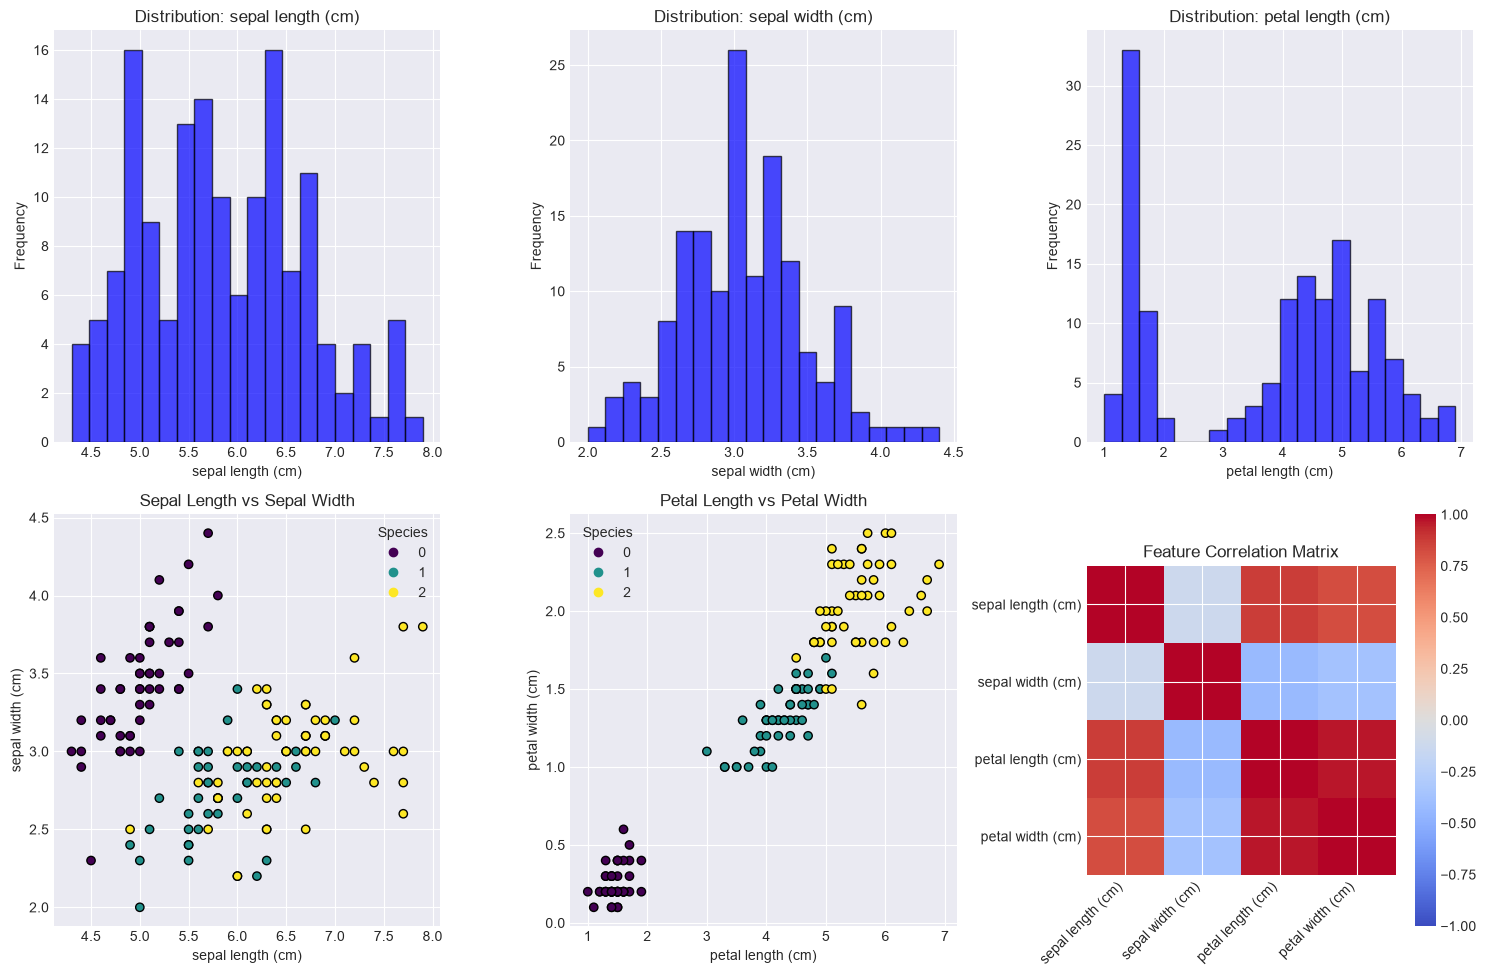

In [6]:

"""
Visualizing the Iris dataset features
Shows: Histograms, scatter plots, correlation matrix
"""

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Distribution plots for each feature
for i, ax in enumerate(axes[0]):
    ax.hist(X[:, i], bins=20, alpha=0.7, color='blue', edgecolor='black')
    ax.set_title(f'Distribution: {dataset.feature_names[i]}')
    ax.set_xlabel(dataset.feature_names[i])
    ax.set_ylabel('Frequency')

# Scatter plot - Feature 0 vs Feature 1
ax = axes[1, 0]
scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolor='black')
ax.legend(*scatter.legend_elements(), title='Species')
ax.set_xlabel(dataset.feature_names[0])
ax.set_ylabel(dataset.feature_names[1])
ax.set_title('Sepal Length vs Sepal Width')

# Scatter plot - Feature 2 vs Feature 3
ax = axes[1, 1]
scatter = ax.scatter(X[:, 2], X[:, 3], c=y, cmap='viridis', edgecolor='black')
ax.legend(*scatter.legend_elements(), title='Species')
ax.set_xlabel(dataset.feature_names[2])
ax.set_ylabel(dataset.feature_names[3])
ax.set_title('Petal Length vs Petal Width')

# Correlation heatmap
ax = axes[1, 2]
corr_matrix = np.corrcoef(X.T)
im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(dataset.feature_names)))
ax.set_yticks(range(len(dataset.feature_names)))
ax.set_xticklabels(dataset.feature_names, rotation=45, ha='right')
ax.set_yticklabels(dataset.feature_names)
ax.set_title('Feature Correlation Matrix')
plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

# Custom Transformers - Estimators vs Transformers

In [7]:

"""
Estimators vs Transformers vs Predictors
Learning to create custom transformers
"""

class FeatureScaler(BaseEstimator, TransformerMixin):
    """
    Custom transformer for feature scaling.
    Demonstrates the Transformer concept in Scikit-learn.
    """
    
    def __init__(self, method='standard'):
        self.method = method
        self.mean_ = None
        self.std_ = None
        self.min_ = None
        self.max_ = None
        
    def fit(self, X, y=None):
        """Fit the transformer on training data"""
        if self.method == 'standard':
            self.mean_ = np.mean(X, axis=0)
            self.std_ = np.std(X, axis=0)
        elif self.method == 'minmax':
            self.min_ = np.min(X, axis=0)
            self.max_ = np.max(X, axis=0)
        return self
    
    def transform(self, X):
        """Transform new data using learned parameters"""
        if self.method == 'standard':
            return (X - self.mean_) / (self.std_ + 1e-8)
        elif self.method == 'minmax':
            return (X - self.min_) / (self.max_ - self.min_ + 1e-8)
        return X

class FeatureSelector(BaseEstimator, TransformerMixin):
    """Custom transformer to select specific features"""
    
    def __init__(self, feature_indices=None):
        self.feature_indices = feature_indices
        
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        if self.feature_indices is not None:
            return X[:, self.feature_indices]
        return X

class DataPreprocessor:
    """Complete preprocessing pipeline combining multiple transformers"""
    
    def __init__(self, scale_method='standard', selected_features=None):
        self.scaler = FeatureScaler(method=scale_method)
        self.selector = FeatureSelector(feature_indices=selected_features)
        
    def fit_transform(self, X, y=None):
        """Fit and transform in one step"""
        X_selected = self.selector.fit_transform(X)
        X_scaled = self.scaler.fit_transform(X_selected)
        return X_scaled
    
    def transform(self, X):
        """Transform new data"""
        X_selected = self.selector.transform(X)
        X_scaled = self.scaler.transform(X_selected)
        return X_scaled

# Test the transformers
X_test = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
scaler = FeatureScaler(method='standard')
scaler.fit(X_test)
X_scaled = scaler.transform(X_test)
print("Original:\n", X_test)
print("\nScaled (mean=0, std=1):\n", X_scaled)

Original:
 [[1 2 3]
 [4 5 6]
 [7 8 9]]

Scaled (mean=0, std=1):
 [[-1.22474487 -1.22474487 -1.22474487]
 [ 0.          0.          0.        ]
 [ 1.22474487  1.22474487  1.22474487]]


# Model Classifiers - Estimators and Predictors

In [8]:

"""
Scikit-learn Workflow, Estimators vs Predictors
Learning about fit(), predict(), score()
"""

class IrisClassifier:
    """Wrapper class for different classifiers"""
    
    def __init__(self, model_type='knn', **kwargs):
        self.model_type = model_type
        self.model = self._create_model(model_type, **kwargs)
        self.is_fitted = False
        
    def _create_model(self, model_type, **kwargs):
        """Factory method to create different models"""
        models = {
            'knn': KNeighborsClassifier,
            'svm': SVC,
            'decision_tree': DecisionTreeClassifier,
            'random_forest': RandomForestClassifier
        }
        
        if model_type not in models:
            raise ValueError(f"Unknown model type: {model_type}")
        
        default_params = {
            'knn': {'n_neighbors': 5},
            'svm': {'kernel': 'rbf', 'probability': True, 'random_state': 42},
            'decision_tree': {'random_state': 42},
            'random_forest': {'n_estimators': 100, 'random_state': 42}
        }
        
        params = default_params.get(model_type, {})
        params.update(kwargs)
        
        return models[model_type](**params)
    
    def fit(self, X, y):
        """Chapter 4: fit() learns patterns from training data"""
        print(f"\n🚀 Training {self.model_type.upper()} classifier...")
        self.model.fit(X, y)
        self.is_fitted = True
        print("✅ Training complete!")
        return self
    
    def predict(self, X):
        """Chapter 4: predict() makes predictions"""
        if not self.is_fitted:
            raise ValueError("Model must be fitted before prediction!")
        return self.model.predict(X)
    
    def predict_proba(self, X):
        """Get prediction probabilities"""
        if hasattr(self.model, 'predict_proba'):
            return self.model.predict_proba(X)
        return None
    
    def score(self, X, y):
        """Chapter 4: score() evaluates model performance"""
        if not self.is_fitted:
            raise ValueError("Model must be fitted before scoring!")
        return self.model.score(X, y)
    
    def evaluate(self, X_test, y_test):
        """Comprehensive model evaluation"""
        y_pred = self.predict(X_test)
        
        print(f"\n📊 {self.model_type.upper()} Performance Report:")
        print("-" * 50)
        print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
        print("\nClassification Report:")
        print(classification_report(y_test, y_pred))
        print("\nConfusion Matrix:")
        print(confusion_matrix(y_test, y_pred))
        
        return y_pred

class ModelComparator:
    """Compare different classifiers' performance"""
    
    def __init__(self, X_train, X_test, y_train, y_test):
        self.X_train = X_train
        self.X_test = X_test
        self.y_train = y_train
        self.y_test = y_test
        self.results = {}
        
    def compare_models(self, model_types=None):
        """Train and compare multiple models"""
        if model_types is None:
            model_types = ['knn', 'svm', 'decision_tree', 'random_forest']
        
        print("="*60)
        print("🔍 MODEL COMPARISON")
        print("="*60)
        
        for model_type in model_types:
            classifier = IrisClassifier(model_type=model_type)
            classifier.fit(self.X_train, self.y_train)
            
            train_score = classifier.score(self.X_train, self.y_train)
            test_score = classifier.score(self.X_test, self.y_test)
            
            self.results[model_type] = {
                'train_score': train_score,
                'test_score': test_score,
                'model': classifier
            }
            
            print(f"\n{model_type.upper()}:")
            print(f"  Train Accuracy: {train_score:.4f}")
            print(f"  Test Accuracy:  {test_score:.4f}")
            print(f"  Overfitting Gap: {train_score - test_score:.4f}")
        
        return self.results
    
    def get_best_model(self):
        """Return the best performing model"""
        best_model = max(self.results, key=lambda x: self.results[x]['test_score'])
        return self.results[best_model]['model']

# Complete ML Pipeline

In [11]:
class IrisPipeline:
    """Complete machine learning pipeline for Iris classification"""
    
    def __init__(self, test_size=0.3, random_state=42):
        self.test_size = test_size
        self.random_state = random_state
        self.dataset = None
        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None
        self.preprocessor = None
        self.best_model = None
        
    def load_data(self):
        """Chapter 3: Load and explore dataset"""
        print("\n" + "="*60)
        print("STEP 1: LOADING AND EXPLORING DATA")
        print("="*60)
        
        self.dataset = IrisDataset()
        df = self.dataset.explore_dataset()
        return df
    
    def split_data(self):
        """Chapter 4: Split data for training and testing"""
        print("\n" + "="*60)
        print("STEP 2: SPLITTING DATA")
        print("="*60)
        
        X, y = self.dataset.get_data()
        
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            X, y, 
            test_size=self.test_size,
            random_state=self.random_state,
            stratify=y
        )
        
        print(f"Training samples: {self.X_train.shape[0]}")
        print(f"Test samples: {self.X_test.shape[0]}")
        
        unique, counts_train = np.unique(self.y_train, return_counts=True)
        unique, counts_test = np.unique(self.y_test, return_counts=True)
        
        print("\nTraining set class distribution:")
        for i, name in enumerate(self.dataset.target_names):
            print(f"  {name}: {counts_train[i]} samples")
            
        print("\nTest set class distribution:")
        for i, name in enumerate(self.dataset.target_names):
            print(f"  {name}: {counts_test[i]} samples")
    
    def preprocess_data(self):
        """Chapter 5-6: Transform and preprocess data"""
        print("\n" + "="*60)
        print("STEP 3: PREPROCESSING DATA")
        print("="*60)
        
        self.preprocessor = DataPreprocessor(
            scale_method='standard',
            selected_features=None
        )
        
        self.X_train_processed = self.preprocessor.fit_transform(self.X_train)
        self.X_test_processed = self.preprocessor.transform(self.X_test)
        
        print(f"Training data shape: {self.X_train_processed.shape}")
        print(f"Test data shape: {self.X_test_processed.shape}")
        print(f"Features after preprocessing: {self.X_train_processed.shape[1]}")
        
        print("\nBefore preprocessing:")
        print(f"  Mean: {self.X_train.mean(axis=0)}")
        print(f"  Std:  {self.X_train.std(axis=0)}")
        
        print("\nAfter preprocessing:")
        mean_values = self.X_train_processed.mean(axis=0)
        std_values = self.X_train_processed.std(axis=0)
        print(f"  Mean: {', '.join([f'{x:.6f}' for x in mean_values])}")
        print(f"  Std:  {', '.join([f'{x:.6f}' for x in std_values])}")
    
    def train_and_compare_models(self):
        """Chapter 4, 6: Train and compare multiple models"""
        print("\n" + "="*60)
        print("STEP 4: MODEL TRAINING AND COMPARISON")
        print("="*60)
        
        comparator = ModelComparator(
            self.X_train_processed, 
            self.X_test_processed,
            self.y_train, 
            self.y_test
        )
        
        results = comparator.compare_models()
        self.best_model = comparator.get_best_model()
        print(f"\n🏆 BEST MODEL: {self.best_model.model_type.upper()}")
        print(f"   Test Accuracy: {self.best_model.score(self.X_test_processed, self.y_test):.4f}")
        
        return results
    
    def evaluate_best_model(self):
        """Chapter 4: Evaluate the best model in detail"""
        print("\n" + "="*60)
        print("STEP 5: FINAL MODEL EVALUATION")
        print("="*60)
        
        y_pred = self.best_model.predict(self.X_test_processed)
        self.best_model.evaluate(self.X_test_processed, self.y_test)
        
        return y_pred
    
    def make_prediction(self, new_sample):
        """Chapter 4: Make predictions on new data"""
        print("\n" + "="*60)
        print("STEP 6: MAKING PREDICTIONS")
        print("="*60)
        
        sample_processed = self.preprocessor.transform(np.array([new_sample]))
        
        prediction = self.best_model.predict(sample_processed)
        probabilities = self.best_model.predict_proba(sample_processed)
        
        print(f"\n📝 New sample: {new_sample}")
        print(f"🎯 Predicted species: {self.dataset.target_names[prediction[0]]}")
        
        if probabilities is not None:
            print(f"\n📊 Prediction probabilities:")
            for i, name in enumerate(self.dataset.target_names):
                print(f"  {name}: {probabilities[0][i]:.4f}")
        else:
            print("\nNote: Probability estimates not available for this model.")
        
        return prediction[0], probabilities

# GRAPH 2 - Model Performance Comparison


STEP 1: LOADING AND EXPLORING DATA
📊 IRIS DATASET EXPLORATION

📌 Dataset Shape:
   - Total Samples: 150
   - Features per Sample: 4

📌 Features (X):
   - sepal length (cm): 4.30 to 7.90
   - sepal width (cm): 2.00 to 4.40
   - petal length (cm): 1.00 to 6.90
   - petal width (cm): 0.10 to 2.50

📌 Target Classes (y):
   - setosa (class 0): 50 samples
   - versicolor (class 1): 50 samples
   - virginica (class 2): 50 samples

📌 First 5 Samples:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species species_name  
0        0       setosa  
1        0       setosa  

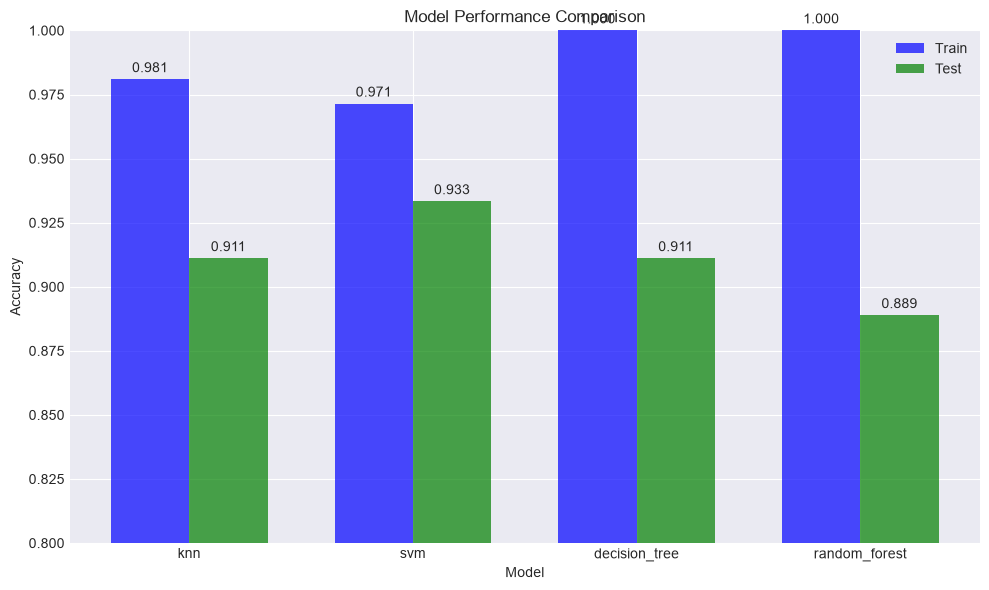

In [12]:
"""
Comparing all models: Training vs Test Accuracy
Shows bar chart with accuracy values
"""

def plot_model_comparison(results):
    """Compare model accuracies"""
    model_names = list(results.keys())
    train_scores = [results[m]['train_score'] for m in model_names]
    test_scores = [results[m]['test_score'] for m in model_names]
    
    x = np.arange(len(model_names))
    width = 0.35
    
    fig, ax = plt.subplots(figsize=(10, 6))
    rects1 = ax.bar(x - width/2, train_scores, width, label='Train', color='blue', alpha=0.7)
    rects2 = ax.bar(x + width/2, test_scores, width, label='Test', color='green', alpha=0.7)
    
    ax.set_xlabel('Model')
    ax.set_ylabel('Accuracy')
    ax.set_title('Model Performance Comparison')
    ax.set_xticks(x)
    ax.set_xticklabels(model_names)
    ax.legend()
    ax.set_ylim(0.8, 1.0)
    
    # Add value labels on bars
    for rect in rects1 + rects2:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                   xy=(rect.get_x() + rect.get_width() / 2, height),
                   xytext=(0, 3),
                   textcoords="offset points",
                   ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()

# Run pipeline to get results
pipeline = IrisPipeline()
pipeline.load_data()
pipeline.split_data()
pipeline.preprocess_data()
results = pipeline.train_and_compare_models()

# Plot comparison
plot_model_comparison(results)

# GRAPH 3 - Confusion Matrix for Best Model


STEP 5: FINAL MODEL EVALUATION

📊 SVM Performance Report:
--------------------------------------------------
Accuracy: 0.9333

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.88      0.93      0.90        15
           2       0.93      0.87      0.90        15

    accuracy                           0.93        45
   macro avg       0.93      0.93      0.93        45
weighted avg       0.93      0.93      0.93        45


Confusion Matrix:
[[15  0  0]
 [ 0 14  1]
 [ 0  2 13]]


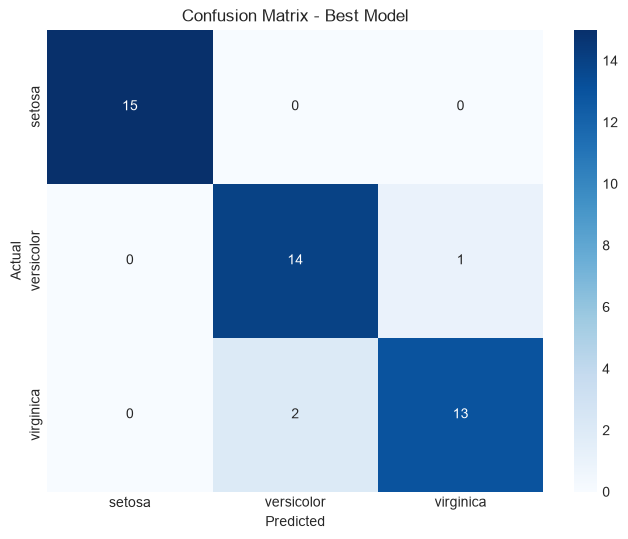

In [13]:

"""
Visualizing the confusion matrix for the best performing model
Shows actual vs predicted classifications
"""

y_pred = pipeline.evaluate_best_model()

# Plot confusion matrix
cm = confusion_matrix(pipeline.y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=pipeline.dataset.target_names,
            yticklabels=pipeline.dataset.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Best Model')
plt.show()

# GRAPH 4 - Decision Boundaries using PCA

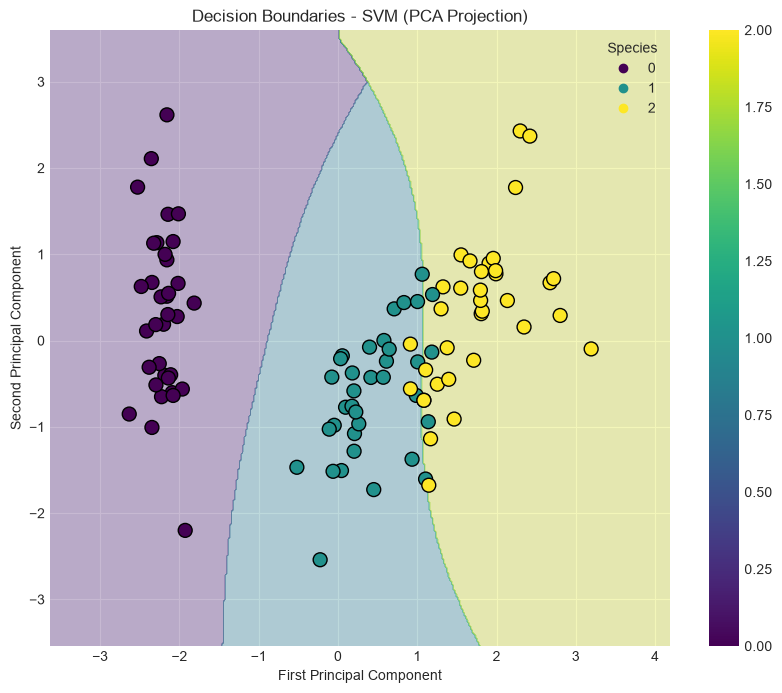

In [14]:

"""
Visualizing how the best model separates the three species
Using PCA to reduce to 2D for visualization
"""

# Reduce to 2D using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(pipeline.X_train_processed)

# Create mesh grid
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Predict on mesh grid
mesh_points = pca.inverse_transform(np.c_[xx.ravel(), yy.ravel()])
Z = pipeline.best_model.predict(mesh_points)
Z = Z.reshape(xx.shape)

# Plot
plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], 
                      c=pipeline.y_train, cmap='viridis', 
                      edgecolor='black', s=100)
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title(f'Decision Boundaries - {pipeline.best_model.model_type.upper()} (PCA Projection)')
plt.legend(*scatter.legend_elements(), title='Species')
plt.colorbar(scatter)
plt.show()

# GRAPH 5 - Feature Importance Analysis

In [15]:

"""
Analyzing which features are most important for prediction
Only works for tree-based models (Decision Tree, Random Forest)
"""

def plot_feature_importance(model, feature_names, model_name):
    """Plot feature importance for tree-based models"""
    if hasattr(model, 'feature_importances_'):
        importance = model.feature_importances_
        indices = np.argsort(importance)[::-1]
        
        plt.figure(figsize=(10, 6))
        plt.title(f'Feature Importance - {model_name}')
        bars = plt.bar(range(len(importance)), importance[indices])
        plt.xticks(range(len(importance)), 
                   [feature_names[i] for i in indices], 
                   rotation=45, ha='right')
        plt.xlabel('Features')
        plt.ylabel('Importance Score')
        
        # Add value labels on bars
        for bar, val in zip(bars, importance[indices]):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{val:.3f}', ha='center', va='bottom')
        
        plt.tight_layout()
        plt.show()
        
        print(f"\n📊 Feature Importance Ranking - {model_name}:")
        for i in range(len(importance)):
            print(f"  {i+1}. {feature_names[indices[i]]}: {importance[indices[i]]:.4f}")
    else:
        print(f"⚠️ Feature importance not available for {model_name}")

# Plot feature importance for the best model if it's tree-based
best_model_name = pipeline.best_model.model_type.upper()
if best_model_name in ['DECISION_TREE', 'RANDOM_FOREST']:
    plot_feature_importance(
        pipeline.best_model.model, 
        pipeline.dataset.feature_names,
        best_model_name
    )
else:
    print(f"ℹ️ Feature importance analysis skipped for {best_model_name} (not a tree-based model)")

ℹ️ Feature importance analysis skipped for SVM (not a tree-based model)


# Make Predictions on New Samples

In [16]:

"""
Testing the trained model on new flower measurements
"""

test_samples = [
    [5.1, 3.5, 1.4, 0.2],  # Likely Setosa
    [6.5, 3.0, 5.2, 2.0],  # Likely Virginica
    [5.9, 3.0, 4.2, 1.5],  # Likely Versicolor
]

for i, sample in enumerate(test_samples, 1):
    print(f"\n{'='*60}")
    print(f"Sample {i}: {sample}")
    prediction, probabilities = pipeline.make_prediction(sample)


Sample 1: [5.1, 3.5, 1.4, 0.2]

STEP 6: MAKING PREDICTIONS

📝 New sample: [5.1, 3.5, 1.4, 0.2]
🎯 Predicted species: setosa

📊 Prediction probabilities:
  setosa: 0.9679
  versicolor: 0.0182
  virginica: 0.0139

Sample 2: [6.5, 3.0, 5.2, 2.0]

STEP 6: MAKING PREDICTIONS

📝 New sample: [6.5, 3.0, 5.2, 2.0]
🎯 Predicted species: virginica

📊 Prediction probabilities:
  setosa: 0.0095
  versicolor: 0.0365
  virginica: 0.9540

Sample 3: [5.9, 3.0, 4.2, 1.5]

STEP 6: MAKING PREDICTIONS

📝 New sample: [5.9, 3.0, 4.2, 1.5]
🎯 Predicted species: versicolor

📊 Prediction probabilities:
  setosa: 0.0139
  versicolor: 0.9460
  virginica: 0.0401


# Summary Statistics

In [17]:

"""
Display overall project statistics and results
"""

print("\n" + "="*60)
print("📊 PROJECT SUMMARY STATISTICS")
print("="*60)

print(f"\n📌 Dataset Information:")
print(f"   - Total Samples: {len(pipeline.dataset.X)}")
print(f"   - Features: {len(pipeline.dataset.feature_names)}")
print(f"   - Classes: {len(pipeline.dataset.target_names)}")

print(f"\n📌 Model Performance:")
print(f"   - Best Model: {pipeline.best_model.model_type.upper()}")
print(f"   - Training Accuracy: {results[pipeline.best_model.model_type]['train_score']:.4f}")
print(f"   - Test Accuracy: {results[pipeline.best_model.model_type]['test_score']:.4f}")

print(f"\n📌 Data Split:")
print(f"   - Training Samples: {len(pipeline.X_train)} ({pipeline.test_size*100:.0f}%)")
print(f"   - Test Samples: {len(pipeline.X_test)} ({pipeline.test_size*100:.0f}%)")

print("\n📌 Class Distribution in Dataset:")
for i, name in enumerate(pipeline.dataset.target_names):
    count = np.sum(pipeline.dataset.y == i)
    print(f"   - {name}: {count} samples ({count/len(pipeline.dataset.y)*100:.1f}%)")

print("\n" + "="*60)
print("✅ PIPELINE COMPLETED SUCCESSFULLY!")
print("="*60)


📊 PROJECT SUMMARY STATISTICS

📌 Dataset Information:
   - Total Samples: 150
   - Features: 4
   - Classes: 3

📌 Model Performance:
   - Best Model: SVM
   - Training Accuracy: 0.9714
   - Test Accuracy: 0.9333

📌 Data Split:
   - Training Samples: 105 (30%)
   - Test Samples: 45 (30%)

📌 Class Distribution in Dataset:
   - setosa: 50 samples (33.3%)
   - versicolor: 50 samples (33.3%)
   - virginica: 50 samples (33.3%)

✅ PIPELINE COMPLETED SUCCESSFULLY!
